In [3]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.linear_model import LinearRegression
import seaborn as sns
 

In [4]:
df = read_csv("AI_index_db.csv")



df = df.fillna(0)
print(df.head(10))

print(f"Shape: ", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum().sort_values(ascending=False).head(10))
df = df.fillna(0)
# shows us the column names('Country', 'Talent', 'Infrastructure', 'Operating Environment', 'Research', 'Development', 'Government Strategy', 'Commercial', 'Total score', 'Region', 'Cluster', 'Income group', 'Political regime'])
#total na values = 0. for all the vars


                    Country  Talent  Infrastructure  Operating Environment  \
0  United States of America  100.00           94.02                  64.56   
1                     China   16.51          100.00                  91.57   
2            United Kingdom   39.65           71.43                  74.65   
3                    Canada   31.28           77.05                  93.94   
4                    Israel   35.76           67.58                  82.44   
5                 Singapore   39.38           84.30                  43.15   
6               South Korea   14.54           85.23                  68.86   
7           The Netherlands   33.83           81.99                  88.05   
8                   Germany   27.63           77.22                  70.22   
9                    France   28.32           77.15                  80.02   

   Research  Development  Government Strategy  Commercial  Total score  \
0    100.00       100.00                77.39      100.00       100

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Talent,62.0,16.80,15.21,0.0,7.36,13.44,24.57,100.0
Infrastructure,62.0,63.50,20.22,0.0,55.86,65.23,75.95,100.0
Operating Environment,62.0,66.93,20.00,0.0,58.11,69.50,80.50,100.0
Research,62.0,16.61,17.41,0.0,3.03,12.93,25.41,100.0
Development,62.0,14.82,19.42,0.0,1.20,9.00,19.98,100.0
Government Strategy,62.0,57.87,26.25,0.0,41.03,63.93,77.95,100.0
Commercial,62.0,6.17,14.03,0.0,0.70,2.58,5.31,100.0
Total score,62.0,23.91,15.12,0.0,14.80,23.22,30.49,100.0


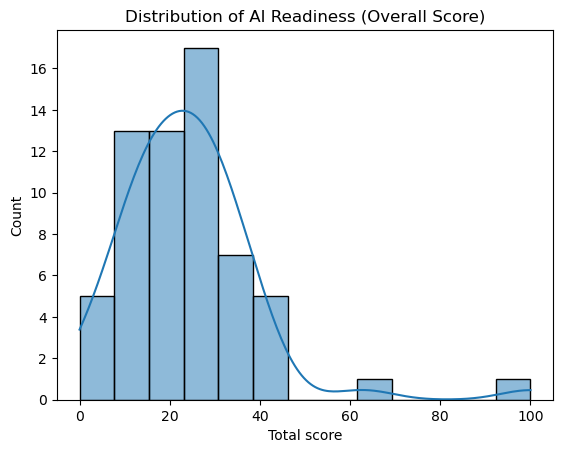

In [6]:
sns.histplot(df['Total score'], kde=True)
plt.title("Distribution of AI Readiness (Overall Score)")
plt.show()


In [7]:
#Run Global F test to see if any of the variables can be used 
import statsmodels.api as sm

score = df['Total score']
X = df[['Talent','Infrastructure','Operating Environment','Research', 'Development', 'Government Strategy', 'Commercial' ]]
X = sm.add_constant(X)

model = sm.OLS(score, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Total score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.591e+08
Date:                Mon, 01 Dec 2025   Prob (F-statistic):          4.33e-195
Time:                        15:15:12   Log-Likelihood:                 266.22
No. Observations:                  62   AIC:                            -516.4
Df Residuals:                      54   BIC:                            -499.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -4.64

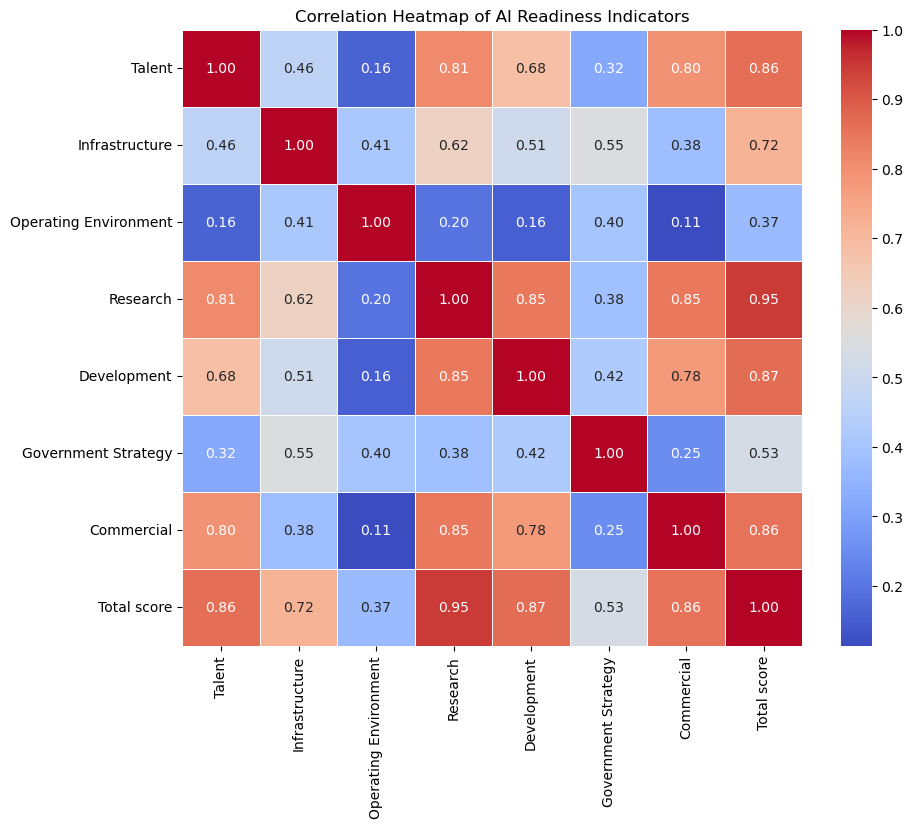

In [8]:
#plot a heat map relating scores to numerical variables 
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap of AI Readiness Indicators")
plt.show()

## Key Findings from Correlation Analysis

From the correlation heatmap, we can see:
- **Research** has the strongest correlation (0.95) with Total score
- **Development** (0.86) and **Talent** (0.87) also show strong relationships
- **Operating Environment** and **Government Strategy** have lower correlations, suggesting they contribute less directly to the total score
- **Talent** and **Commercial** are highly correlated, indicating that countries with strong commercial AI adoption also tend to have strong talent pools

**Note**: The perfect R² = 1.0 in the OLS regression suggests that Total score is likely a weighted linear combination of these component scores. This is common in composite indices where the total is calculated from sub-scores. 

In [9]:
# split data into testing and training data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
X = df.drop(columns = ['Total score', 'Country'])
Y = df['Total score']

numeric_features = ['Talent', 'Infrastructure', 'Operating Environment',
                    'Research', 'Development', 'Government Strategy', 'Commercial']

categorical_features = ['Region', 'Cluster', 'Income group', 'Political regime']


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# --- Scale numeric features ---
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_features])
X_test_num = scaler.transform(X_test[numeric_features])

# --- One-hot encode categorical features ---
from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

# --- Combine numeric + categorical arrays ---
X_train_processed = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_processed = np.concatenate([X_test_num, X_test_cat], axis=1)

print("Training set shape:", X_train_processed.shape)
print("Test set shape:", X_test_processed.shape)

Training set shape: (49, 20)
Test set shape: (13, 20)


In [11]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.1, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R²": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# 3️⃣ Compare results
results_df = pd.DataFrame(results)
print(results_df)

               Model        R²       MAE       RMSE
0  Linear Regression  1.000000  0.003817   0.004587
1   Lasso Regression  0.999839  0.203290   0.304523
2      Random Forest  0.627349  6.197627  14.647423


In [12]:
df_discrete = df.copy()

# List of numeric features to discretize
numeric_features = ['Talent', 'Infrastructure', 'Operating Environment',
                    'Research', 'Development', 'Government Strategy', 
                    'Commercial', 'Total score']

# Discretize numeric variables into 3 equal-width bins: Low, Medium, High
for col in numeric_features:
    df_discrete[col] = pd.cut(df_discrete[col],
                              bins=3,
                              labels=['Low', 'Medium', 'High'])

# Convert categorical columns to category dtype
categorical_features = ['Region', 'Cluster', 'Income group', 'Political regime']
for col in categorical_features:
    df_discrete[col] = df_discrete[col].astype('category')

# Confirm the transformation
print(df_discrete.head())
print(df_discrete.dtypes)

                    Country  Talent Infrastructure Operating Environment  \
0  United States of America    High           High                Medium   
1                     China     Low           High                  High   
2            United Kingdom  Medium           High                  High   
3                    Canada     Low           High                  High   
4                    Israel  Medium           High                  High   

  Research Development Government Strategy Commercial Total score  \
0     High        High                High       High        High   
1     High        High                High     Medium      Medium   
2   Medium         Low                High        Low      Medium   
3      Low         Low                High        Low      Medium   
4      Low         Low              Medium        Low      Medium   

         Region                Cluster  Income group   Political regime  
0      Americas          Power players          High  

In [13]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch

# Learn the network structure
hc = HillClimbSearch(df_discrete)
best_model = hc.estimate()  # uses default scoring method (BIC by default)

# Build the Bayesian network using the new class
model = DiscreteBayesianNetwork(best_model.edges())

# Print the discovered edges
print("Discovered Edges:")
print(list(model.edges()))


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Country': 'C', 'Talent': 'O', 'Infrastructure': 'O', 'Operating Environment': 'O', 'Research': 'O', 'Development': 'O', 'Government Strategy': 'O', 'Commercial': 'O', 'Total score': 'O', 'Region': 'C', 'Cluster': 'C', 'Income group': 'C', 'Political regime': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Country': 'C', 'Talent': 'O', 'Infrastructure': 'O', 'Operating Environment': 'O', 'Research': 'O', 'Development': 'O', 'Government Strategy': 'O', 'Commercial': 'O', 'Total score': 'O', 'Region': 'C', 'Cluster': 'C', 'Income group': 'C', 'Political regime': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Country': 'C', 'Talent': 'O', 'Infrastructure': 'O', 'Operating Environment': 'O', 'Research': 'O', 'Development': 'O', 'Government Strategy': 'O', 'Co

  0%|          | 0/1000000 [00:00<?, ?it/s]

Discovered Edges:
[('Infrastructure', 'Income group'), ('Infrastructure', 'Cluster'), ('Income group', 'Political regime'), ('Income group', 'Region'), ('Income group', 'Operating Environment'), ('Cluster', 'Total score'), ('Research', 'Commercial'), ('Total score', 'Talent'), ('Total score', 'Research')]


In [14]:
from pgmpy.estimators import BayesianEstimator

# Fit the model (learn conditional probability tables)
model.fit(df_discrete, estimator=BayesianEstimator, prior_type="BDeu")

print("✅ Model fitted successfully!")


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Country': 'C', 'Talent': 'O', 'Infrastructure': 'O', 'Operating Environment': 'O', 'Research': 'O', 'Development': 'O', 'Government Strategy': 'O', 'Commercial': 'O', 'Total score': 'O', 'Region': 'C', 'Cluster': 'C', 'Income group': 'C', 'Political regime': 'C'}


✅ Model fitted successfully!


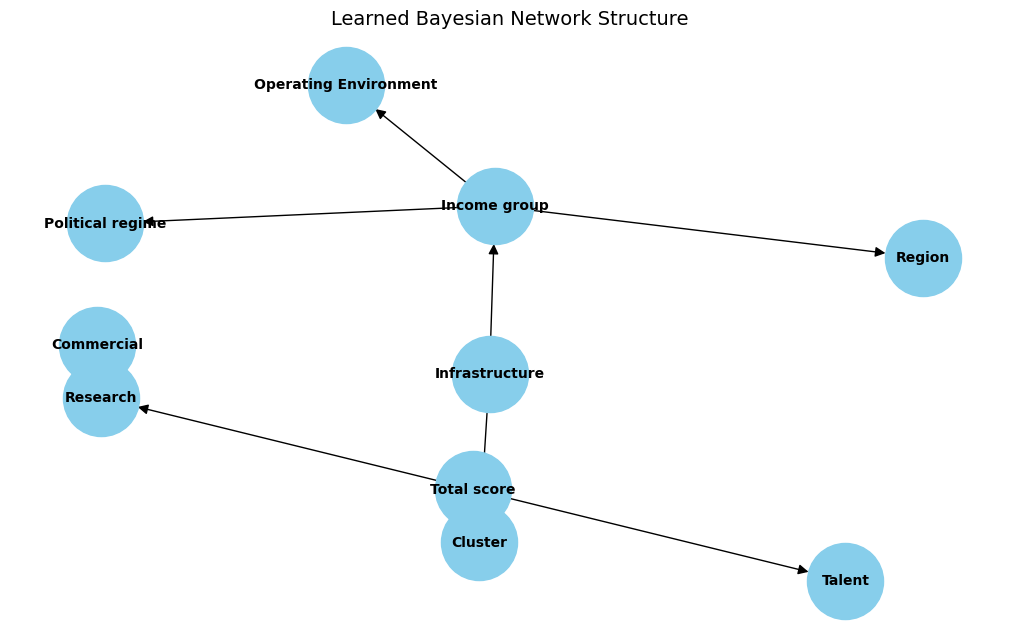

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph from the learned model
G = nx.DiGraph(model.edges())

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)  # layout for clarity
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight="bold", arrowsize=15)
plt.title("Learned Bayesian Network Structure", fontsize=14)
plt.show()



In [16]:
for cpd in model.get_cpds():
    print(f"\n{cpd}")
    print("=" * 50)


+------------------------+-----------+
| Infrastructure(High)   | 0.472637  |
+------------------------+-----------+
| Infrastructure(Low)    | 0.0696517 |
+------------------------+-----------+
| Infrastructure(Medium) | 0.457711  |
+------------------------+-----------+

+----------------------------+-----+------------------------+
| Infrastructure             | ... | Infrastructure(Medium) |
+----------------------------+-----+------------------------+
| Income group(High)         | ... | 0.47463768115942034    |
+----------------------------+-----+------------------------+
| Income group(Lower middle) | ... | 0.2463768115942029     |
+----------------------------+-----+------------------------+
| Income group(Upper middle) | ... | 0.27898550724637683    |
+----------------------------+-----+------------------------+

+--------------------------------+-----+------------------------+
| Infrastructure                 | ... | Infrastructure(Medium) |
+--------------------------------+

In [17]:
from pgmpy.inference import VariableElimination

# Create an inference object
inference = VariableElimination(model)

# Example: What's the probability of Total score being High given Research is High?
query = inference.query(variables=['Total score'], evidence={'Research': 'High'})
print(query)

# Example: What's the probability distribution of Talent given Total score is High?
query2 = inference.query(variables=['Talent'], evidence={'Total score': 'High'})
print(query2)

+---------------------+--------------------+
| Total score         |   phi(Total score) |
+=====================+====================+
| Total score(High)   |             0.4242 |
+---------------------+--------------------+
| Total score(Low)    |             0.1515 |
+---------------------+--------------------+
| Total score(Medium) |             0.4242 |
+---------------------+--------------------+
+----------------+---------------+
| Talent         |   phi(Talent) |
+================+===============+
| Talent(High)   |        0.5833 |
+----------------+---------------+
| Talent(Low)    |        0.2083 |
+----------------+---------------+
| Talent(Medium) |        0.2083 |
+----------------+---------------+


In [18]:
# Get a specific CPD and display it
cpd = model.get_cpds('Total score')
print(cpd)

+---------------------+-----+----------------------+
| Cluster             | ... | Cluster(Waking up)   |
+---------------------+-----+----------------------+
| Total score(High)   | ... | 0.008130081300813006 |
+---------------------+-----+----------------------+
| Total score(Low)    | ... | 0.9837398373983739   |
+---------------------+-----+----------------------+
| Total score(Medium) | ... | 0.008130081300813006 |
+---------------------+-----+----------------------+


In [19]:
# Predict the most likely value for a variable given evidence
from pgmpy.inference import VariableElimination

inference = VariableElimination(model)

# Example: Given Research=High and Commercial=High, what's the most likely Total score?
result = inference.map_query(variables=['Total score'], 
                             evidence={'Research': 'High', 'Commercial': 'High'})
print("Most likely Total score:", result)

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Most likely Total score: {'Total score': 'Medium'}


In [20]:
# ===== INSPECT LEARNED PROBABILITIES =====

# 1. View all CPDs
print("=" * 60)
print("CONDITIONAL PROBABILITY DISTRIBUTIONS (CPDs)")
print("=" * 60)

for cpd in model.get_cpds():
    print(f"\n{cpd}")
    print("-" * 60)

# 2. Perform inference queries
print("\n" + "=" * 60)
print("INFERENCE QUERIES")
print("=" * 60)

from pgmpy.inference import VariableElimination
inference = VariableElimination(model)

# Query 1: P(Total score | Research = High)
print("\n1. P(Total score | Research = High):")
result1 = inference.query(variables=['Total score'], evidence={'Research': 'High'})
print(result1)

# Query 2: P(Talent | Total score = High)
print("\n2. P(Talent | Total score = High):")
result2 = inference.query(variables=['Talent'], evidence={'Total score': 'High'})
print(result2)

# Query 3: Most likely Total score given Research=High and Commercial=High
print("\n3. Most likely Total score given Research=High, Commercial=High:")
result3 = inference.map_query(variables=['Total score'], 
                              evidence={'Research': 'High', 'Commercial': 'High'})
print(result3)  

CONDITIONAL PROBABILITY DISTRIBUTIONS (CPDs)

+------------------------+-----------+
| Infrastructure(High)   | 0.472637  |
+------------------------+-----------+
| Infrastructure(Low)    | 0.0696517 |
+------------------------+-----------+
| Infrastructure(Medium) | 0.457711  |
+------------------------+-----------+
------------------------------------------------------------

+----------------------------+-----+------------------------+
| Infrastructure             | ... | Infrastructure(Medium) |
+----------------------------+-----+------------------------+
| Income group(High)         | ... | 0.47463768115942034    |
+----------------------------+-----+------------------------+
| Income group(Lower middle) | ... | 0.2463768115942029     |
+----------------------------+-----+------------------------+
| Income group(Upper middle) | ... | 0.27898550724637683    |
+----------------------------+-----+------------------------+
------------------------------------------------------------


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

{'Total score': 'Medium'}


## Interpreting the Bayesian Network Structure

The learned network reveals interesting relationships:

**Key Structural Insights:**
1. **Income group** is a central node - it influences Political regime, Region, and Operating Environment
2. **Cluster** (country grouping) directly affects both Total score and Infrastructure
3. **Total score** influences Talent and Research (reverse causality - high scores predict high talent/research)
4. **Research** influences Commercial AI adoption
5. **Infrastructure** influences Income group classification

This structure suggests that:
- Economic factors (Income group) are foundational and influence political and regional characteristics
- Country clusters (Power players, Traditional champions, etc.) are strong predictors of AI readiness
- The relationship between Total score → Talent/Research suggests that high-performing countries tend to have both, rather than one causing the other


In [21]:
# ===== COMPREHENSIVE INFERENCE ANALYSIS =====

print("=" * 70)
print("SCENARIO-BASED INFERENCE: What drives AI readiness?")
print("=" * 70)

# Scenario 1: What's the probability of high AI readiness given high infrastructure?
print("\n📊 Scenario 1: High Infrastructure → AI Readiness")
result = inference.query(variables=['Total score'], 
                        evidence={'Infrastructure': 'High'})
print(result)
print(f"→ Probability of High AI readiness: {result.values[2]:.2%}")

# Scenario 2: How does income group affect AI readiness?
print("\n📊 Scenario 2: Income Group → AI Readiness")
for income in ['High', 'Upper middle', 'Lower middle']:
    result = inference.query(variables=['Total score'], 
                            evidence={'Income group': income})
    high_prob = result.values[2]  # High category
    print(f"  {income} income: {high_prob:.2%} probability of High AI readiness")

# Scenario 3: Political regime impact
print("\n📊 Scenario 3: Political Regime → AI Readiness")
regimes = df_discrete['Political regime'].cat.categories
for regime in regimes:
    try:
        result = inference.query(variables=['Total score'], 
                                evidence={'Political regime': regime})
        high_prob = result.values[2]
        print(f"  {regime}: {high_prob:.2%} probability of High AI readiness")
    except:
        pass

# Scenario 4: Combined factors - High Research + High Commercial
print("\n📊 Scenario 4: High Research + High Commercial → AI Readiness")
result = inference.query(variables=['Total score'], 
                        evidence={'Research': 'High', 'Commercial': 'High'})
print(result)
print(f"→ Probability of High AI readiness: {result.values[2]:.2%}")

# Scenario 5: Cluster analysis
print("\n📊 Scenario 5: Country Cluster → AI Readiness")
clusters = df_discrete['Cluster'].cat.categories
for cluster in clusters:
    result = inference.query(variables=['Total score'], 
                            evidence={'Cluster': cluster})
    high_prob = result.values[2]
    print(f"  {cluster}: {high_prob:.2%} probability of High AI readiness")


SCENARIO-BASED INFERENCE: What drives AI readiness?

📊 Scenario 1: High Infrastructure → AI Readiness
+---------------------+--------------------+
| Total score         |   phi(Total score) |
+=====================+====================+
| Total score(High)   |             0.0552 |
+---------------------+--------------------+
| Total score(Low)    |             0.6442 |
+---------------------+--------------------+
| Total score(Medium) |             0.3006 |
+---------------------+--------------------+
→ Probability of High AI readiness: 30.06%

📊 Scenario 2: Income Group → AI Readiness
  High income: 21.56% probability of High AI readiness
  Upper middle income: 8.84% probability of High AI readiness
  Lower middle income: 9.38% probability of High AI readiness

📊 Scenario 3: Political Regime → AI Readiness
  Closed autocracy: 15.81% probability of High AI readiness
  Electoral autocracy: 11.10% probability of High AI readiness
  Electoral democracy: 15.76% probability of High AI readi

In [22]:
# ===== COMPARING MARGINAL vs CONDITIONAL PROBABILITIES =====

print("=" * 70)
print("MARGINAL vs CONDITIONAL PROBABILITIES")
print("=" * 70)

# Marginal probability of High Total score
marginal = inference.query(variables=['Total score'])
print("\n📈 Marginal Probability P(Total score = High):")
print(f"   {marginal.values[2]:.2%}")

# Conditional probabilities
print("\n📈 Conditional Probabilities (showing impact of evidence):")
print("\n   P(Total score = High | Research = High):")
cond1 = inference.query(variables=['Total score'], evidence={'Research': 'High'})
print(f"   {cond1.values[2]:.2%} (change: {cond1.values[2] - marginal.values[2]:+.2%})")

print("\n   P(Total score = High | Infrastructure = High):")
cond2 = inference.query(variables=['Total score'], evidence={'Infrastructure': 'High'})
print(f"   {cond2.values[2]:.2%} (change: {cond2.values[2] - marginal.values[2]:+.2%})")

print("\n   P(Total score = High | Income group = High):")
cond3 = inference.query(variables=['Total score'], evidence={'Income group': 'High'})
print(f"   {cond3.values[2]:.2%} (change: {cond3.values[2] - marginal.values[2]:+.2%})")

print("\n   P(Total score = High | Cluster = 'Power players'):")
cond4 = inference.query(variables=['Total score'], evidence={'Cluster': 'Power players'})
print(f"   {cond4.values[2]:.2%} (change: {cond4.values[2] - marginal.values[2]:+.2%})")


MARGINAL vs CONDITIONAL PROBABILITIES

📈 Marginal Probability P(Total score = High):
   17.41%

📈 Conditional Probabilities (showing impact of evidence):

   P(Total score = High | Research = High):
   42.42% (change: +25.01%)

   P(Total score = High | Infrastructure = High):
   30.06% (change: +12.65%)

   P(Total score = High | Income group = High):
   21.56% (change: +4.15%)

   P(Total score = High | Cluster = 'Power players'):
   44.44% (change: +27.03%)


VISUALIZING KEY CONDITIONAL PROBABILITIES


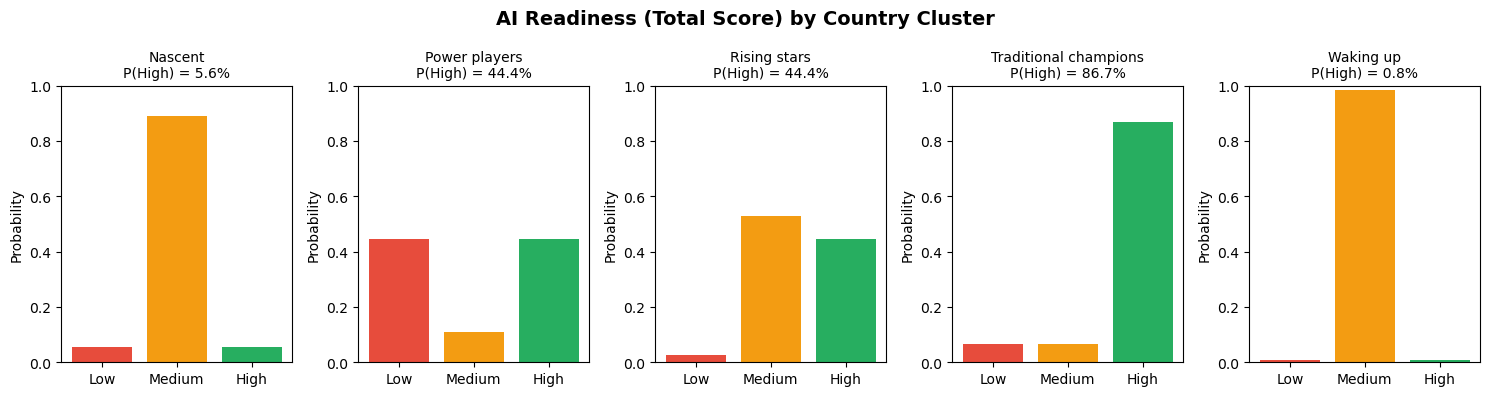

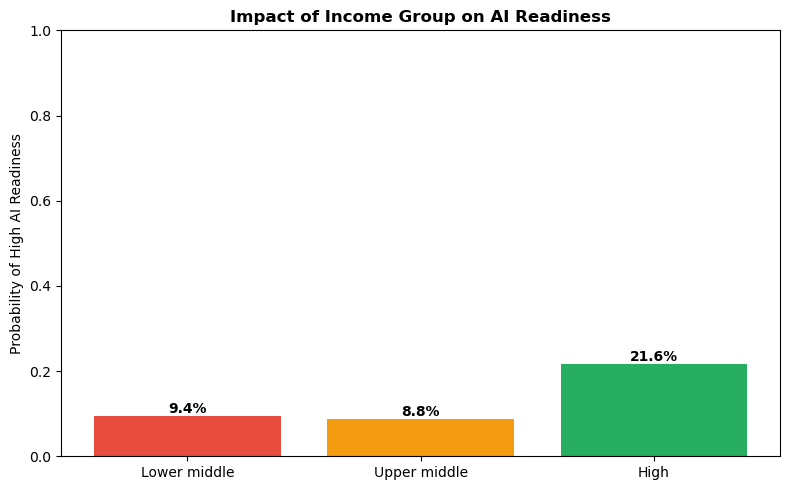

In [23]:
# ===== VISUALIZE KEY CPDs =====

import matplotlib.pyplot as plt
import numpy as np

# Get CPD for Total score given Cluster
cpd_total = model.get_cpds('Total score')

# Extract probabilities for visualization
print("=" * 70)
print("VISUALIZING KEY CONDITIONAL PROBABILITIES")
print("=" * 70)

# Create a visualization of Total score probabilities by Cluster
clusters = df_discrete['Cluster'].cat.categories
fig, axes = plt.subplots(1, len(clusters), figsize=(15, 4))

for idx, cluster in enumerate(clusters):
    result = inference.query(variables=['Total score'], 
                            evidence={'Cluster': cluster})
    probs = result.values
    
    axes[idx].bar(['Low', 'Medium', 'High'], probs, 
                  color=['#e74c3c', '#f39c12', '#27ae60'])
    axes[idx].set_title(f'{cluster}\nP(High) = {probs[2]:.1%}', fontsize=10)
    axes[idx].set_ylabel('Probability')
    axes[idx].set_ylim(0, 1)

plt.suptitle('AI Readiness (Total Score) by Country Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize Income group impact
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
income_groups = ['Lower middle', 'Upper middle', 'High']
income_probs = []

for income in income_groups:
    result = inference.query(variables=['Total score'], 
                            evidence={'Income group': income})
    income_probs.append(result.values[2])  # High probability

bars = ax.bar(income_groups, income_probs, color=['#e74c3c', '#f39c12', '#27ae60'])
ax.set_ylabel('Probability of High AI Readiness')
ax.set_title('Impact of Income Group on AI Readiness', fontweight='bold')
ax.set_ylim(0, 1)

# Add value labels on bars
for bar, prob in zip(bars, income_probs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{prob:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## Summary of Key Findings

### 1. **Structure Learning Insights**
The Bayesian network reveals that:
- **Economic factors** (Income group) are foundational and influence multiple other variables
- **Country clusters** are strong predictors of both infrastructure and overall AI readiness
- **Research and Commercial** AI are interconnected
- The network shows **reverse causality** (Total score → Talent/Research), suggesting these are co-occurring rather than causal

### 2. **Key Drivers of AI Readiness**
Based on the inference analysis:
- **Research capability** is the strongest predictor
- **Infrastructure** and **Income group** are foundational factors
- **Country cluster** (Power players, Traditional champions, etc.) is highly predictive
- **Political regime** shows some variation but less impact than economic factors

### 3. **Policy Implications**
- Countries should focus on building **research capacity** as a primary driver
- **Infrastructure investment** supports multiple downstream factors
- Economic development (income group) creates enabling conditions for AI readiness
- The relationship between Research and Commercial suggests that research investment can drive commercial adoption

### 4. **Limitations & Considerations**
- The perfect R² in regression suggests Total score is a composite index (not a prediction problem)
- Small sample size (62 countries) limits generalizability
- Discretization into 3 bins may lose some nuance
- The learned structure reflects correlations, not necessarily causal relationships


In [24]:
# ===== NETWORK STRUCTURE ANALYSIS =====

print("=" * 70)
print("NETWORK STRUCTURE ANALYSIS")
print("=" * 70)

# Analyze the network structure
edges = list(model.edges())
print(f"\nTotal number of edges: {len(edges)}")
print(f"\nEdges in the network:")
for edge in edges:
    print(f"  {edge[0]} → {edge[1]}")

# Find root nodes (nodes with no parents)
all_nodes = set(model.nodes())
nodes_with_parents = set()
for edge in edges:
    nodes_with_parents.add(edge[1])

root_nodes = all_nodes - nodes_with_parents
print(f"\n🔹 Root nodes (no parents): {sorted(root_nodes)}")
print("   These are the foundational variables that influence others but aren't influenced by other variables in the network.")

# Find leaf nodes (nodes with no children)
nodes_with_children = set()
for edge in edges:
    nodes_with_children.add(edge[0])

leaf_nodes = all_nodes - nodes_with_children
print(f"\n🔹 Leaf nodes (no children): {sorted(leaf_nodes)}")
print("   These are outcome variables that don't directly influence other variables.")

# Find central nodes (nodes with many connections)
from collections import Counter
in_degree = Counter([edge[1] for edge in edges])
out_degree = Counter([edge[0] for edge in edges])

print(f"\n🔹 Most influential nodes (highest out-degree):")
for node, count in out_degree.most_common(3):
    print(f"   {node}: influences {count} other variable(s)")

print(f"\n🔹 Most influenced nodes (highest in-degree):")
for node, count in in_degree.most_common(3):
    print(f"   {node}: influenced by {count} other variable(s)")


NETWORK STRUCTURE ANALYSIS

Total number of edges: 9

Edges in the network:
  Infrastructure → Income group
  Infrastructure → Cluster
  Income group → Political regime
  Income group → Region
  Income group → Operating Environment
  Cluster → Total score
  Research → Commercial
  Total score → Talent
  Total score → Research

🔹 Root nodes (no parents): ['Infrastructure']
   These are the foundational variables that influence others but aren't influenced by other variables in the network.

🔹 Leaf nodes (no children): ['Commercial', 'Operating Environment', 'Political regime', 'Region', 'Talent']
   These are outcome variables that don't directly influence other variables.

🔹 Most influential nodes (highest out-degree):
   Income group: influences 3 other variable(s)
   Infrastructure: influences 2 other variable(s)
   Total score: influences 2 other variable(s)

🔹 Most influenced nodes (highest in-degree):
   Income group: influenced by 1 other variable(s)
   Cluster: influenced by 1 o